In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.visualization.wcsaxes import WCSAxes
#from wcsaxes import WCSAxes
import matplotlib.patches as patches
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

font = {'size'   : 6}
mpl.rc('font', **font)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
#minorLocator = MultipleLocator(10)

#import matplotlib.style
#mpl.style.use('classic')

#levs = np.arange(10.,106.,10) #np.array([5,12,19,26,33,40,47,54,61,68])
#rms = 0.05 #0.07
levs = np.arange(5.,46.,5) #np.array([5,12,19,26,33,40,47,54,61,68])
rms = 0.11 #0.07
polimin = 0
polimax = 0.2 #in Jy/beam km/s

xoffset=1
yoffset=0
spax = 10 #pixels between pol segements
spay = 7

d0 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red.pa18.fits")
h0 = d0[0].header
ps = h0['CDELT2']*3600 #pixel size in arcsec
ra0_deg = h0['CRVAL1']
dec0_deg = h0['CRVAL2']
fsx = 7 #figure size x in arcsec
fsy = 7 #figure size y in arcsec
crarc1 = 0 #xoffset of plot center in arcsec
crarc2 = 4 #yoffset of plot center in arcsec
sx = np.round(fsx/ps) #x size
sy = np.round(fsy/ps) #y size
h0['NAXIS1'] = sx
h0['CRPIX1'] = round(sx/2) + round(crarc1/ps)
h0['NAXIS2'] = sy
h0['CRPIX2'] = round(sy/2) + round(crarc2/ps)
wcs = WCS(h0)
#print(repr(h0))
d0.close()
            
#4a1: 03 29 10.529 31 13 31.05 #from Reipurth 2002
#4a2: 03 29 10.421 31 13 32.21
ra=np.array([3,29,10.529])
dec=np.array([31,13,31.05])
dec1_deg=dec[0]+dec[1]/60+dec[2]/3600
ra1_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec1_pix_offset = h0['CRPIX2']+(dec1_deg-dec0_deg)*3600/ps
ra1_pix_offset = h0['CRPIX1']-(ra1_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

ra=np.array([3,29,10.421])
dec=np.array([31,13,32.21])
dec2_deg=dec[0]+dec[1]/60+dec[2]/3600
ra2_deg=(ra[0]+ra[1]/60+ra[2]/3600)*15
dec2_pix_offset = h0['CRPIX2']+(dec2_deg-dec0_deg)*3600/ps
ra2_pix_offset = h0['CRPIX1']-(ra2_deg-ra0_deg)*3600*np.cos(dec0_deg*np.pi/180)/ps

pvdec_pix_offset = h0['CRPIX2']-3.42/ps
pvra_pix_offset = h0['CRPIX1']-0.34/ps

d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.mom0.fits")
data1 = d1[0].data
data2 = data1.squeeze()
h = d1[0].header
naxis = h['NAXIS1']
d1.close() 

pix_min_y = int((naxis-sx)/2) - round(crarc1/ps)
pix_max_y = int(pix_min_y + sx) #naxis-pix_min_y - round(crarc1/ps)
pix_min_x = int((naxis-sy)/2) - round(crarc2/ps)
pix_max_x = int(pix_min_x + sy) #naxis-pix_min_x - round(crarc2/ps)
print(pix_min_y,pix_max_y,pix_min_x,pix_max_x)
#print pix_min_y,pix_max_y,pix_min_x,pix_max_x
mom0 = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]
           
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.mom0.blue.fits")
data1 = d1[0].data
data2 = data1.squeeze()
d1.close() 
mom0blue = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]

d2 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.mom1.mask.fits")
data1 = d2[0].data
data2 = data1.squeeze()
d2.close() 
mom1 = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]
mom1[mom0 < levs[0]*rms] = 'nan'

d2 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.mom1.blue.mask.fits")
data1 = d2[0].data
data2 = data1.squeeze()
d2.close() 
mom1blue = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]
mom1blue[mom0blue < levs[0]*rms] = 'nan'

d3 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/red_dust/red.pa.fits")
data1 = d3[0].data
data2 = data1.squeeze()*np.pi/180
d3.close() 
padust = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]

d4 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.mom0.pa.fits")
data1 = d4[0].data
data2 = (data1.squeeze()+90)*np.pi/180
d4.close() 
pamom0 = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]

d5 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.mom0.poli.fits")
data1 = d5[0].data
data2 = data1.squeeze()
d5.close() 
polimom0 = data2[pix_min_x:pix_max_x,pix_min_y:pix_max_y]

380 520 300 440


In [3]:
from scipy.optimize import curve_fit

d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.pv_pa81.5.fits")
cdelt1 = d1[0].header['CDELT1'] #delta v
crval1 = d1[0].header['CRVAL1'] #+cdelt1/2 #v0
cdelt2 = d1[0].header['CDELT2'] #delta p
crval2 = d1[0].header['CRVAL2'] #p0
#print cdelt1, crval1, cdelt2, crval2 
data1 = d1[0].data
pv = data1.squeeze()
pvM_rot = pv #np.flipud(pv_tmp)
d1.close()

vplot = round((0*1000-crval1)/cdelt1)
vplot2 = round((10*1000-crval1)/cdelt1)
vplot3 = round((20*1000-crval1)/cdelt1)

print(vplot,vplot2,vplot3)
print(cdelt1)
#print np.shape(pvM_rot[:,vplot])
#print(levs1)

def gaus2(x,a,x0,sigma,b):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))+b

xf = np.arange(501)

dataf = pvM_rot[:,21]
popt21,pcov21 = curve_fit(gaus2,xf,dataf,p0=[np.amax(dataf),250,10,0])
print("fit21",popt21)
print(np.sqrt(np.diag(pcov21)))

dataf = pvM_rot[:,20]
popt20,pcov20 = curve_fit(gaus2,xf,dataf,p0=[np.amax(dataf),250,10,0])
print("fit20",popt20)
print(np.sqrt(np.diag(pcov20)))

dataf = pvM_rot[:,19]
popt19,pcov19 = curve_fit(gaus2,xf,dataf,p0=[np.amax(dataf),250,10,0])
print("fit19",popt19)
print(np.sqrt(np.diag(pcov19)))

dataf = pvM_rot[:,18]
popt18,pcov18 = curve_fit(gaus2,xf,dataf,p0=[np.amax(dataf),250,10,0])
print("fit18",popt18)
print(np.sqrt(np.diag(pcov18)))

dataf = pvM_rot[:,17]
popt17,pcov17 = curve_fit(gaus2,xf,dataf,p0=[np.amax(dataf),250,10,0])
print("fit17",popt17)
print(np.sqrt(np.diag(pcov17)))

vel = np.array([21,20,19,18,17])
pfit = np.array([popt21[1],popt20[1],popt19[1],popt18[1],popt17[1]])
pfiterr = np.array([np.sqrt(popt21[2]),np.sqrt(popt20[2]),np.sqrt(popt19[2]),
                    np.sqrt(popt18[2]),np.sqrt(popt17[2])])

print('vel=', vel)
print('pfit=', pfit)
print('pfiterr=', pfiterr)
    
polyfit, polycov = np.polyfit(vel, pfit, 1, cov=True, w=1/pfiterr)
polyfiterr = np.sqrt(np.diag(polycov))
print('polyfit=', polyfit[0],polyfit[1])
print('polyfiterr=', polyfiterr)
    
print('slope in arcsec/(km/s) =', polyfit[0]*cdelt2)
print('sloperr in arcsec/(km/s) =', polyfiterr[0]*cdelt2)
print('slope in au/(km/s) =', polyfit[0]*cdelt2*300)
print('sloperr in au/(km/s) =', polyfiterr[0]*cdelt2*300)


25 22 19
-3174.99995232
fit21 [ 3.08083531e-01  2.56307166e+02  8.98729375e+00 -1.71039049e-02]
[0.00869582 0.29119855 0.29627172 0.00132336]
fit20 [ 2.84391461e-01  2.55695305e+02  6.10531858e+00 -7.07941762e-03]
[0.00767108 0.18943586 0.19161103 0.00094824]
fit19 [ 2.49888691e-01  2.58682948e+02  7.40717677e+00 -1.12611673e-03]
[0.00269538 0.09182271 0.09311934 0.0003694 ]
fit18 [ 2.25515246e-01  2.59942902e+02  6.65109494e+00 -4.37965420e-04]
[0.00198798 0.06741589 0.06826395 0.00025719]
fit17 [ 1.89549762e-01  2.62628458e+02  6.20129510e+00 -1.11441338e-03]
[0.00119264 0.04487902 0.04540295 0.00014865]
vel= [21 20 19 18 17]
pfit= [256.30716557 255.69530527 258.68294844 259.94290194 262.62845823]
pfiterr= [2.99788154 2.47089429 2.7216129  2.57897168 2.49023997]
polyfit= -1.7730069991510957 292.25721216663317
polyfiterr= [0.32809813 6.2112814 ]
slope in arcsec/(km/s) = -0.0717079271542315
sloperr in arcsec/(km/s) = 0.013269680568408809
slope in au/(km/s) = -21.512378146269448
sloperr

/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_37316/1596382411.py:208: UserWarning: The following kwargs were not used by contour: 'aspect'
  ax3.contourf(pvM_rot,levels=levs1, cmap='Greys',alpha=1,
/var/folders/sx/1b55yzdj67g8dg8fyg5xygx00000gn/T/ipykernel_37316/1596382411.py:248: UserWarning: The following kwargs were not used by contour: 'aspect'
  ax4.contourf(pvM_rot,levels=levs1, cmap='Greys',alpha=1,


34.58267864589043 3.086615180777893 209.04922495179048 307.9508147488382


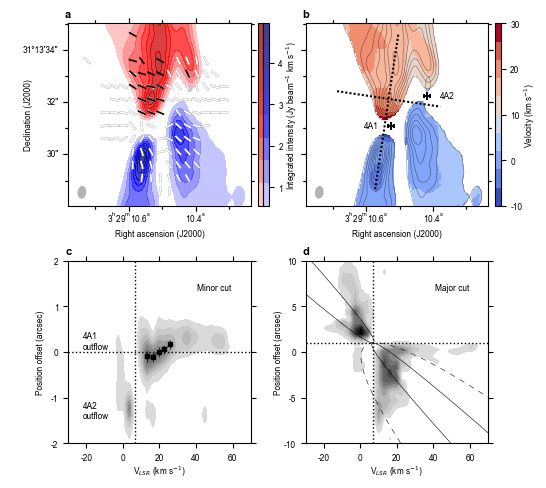

In [4]:
sc = 21 #scale
wd = 0.011 #width

fig = plt.figure(figsize = (7,7))
left = 0.2  # the left side of the subplots of the figure
right = 0.8   # the right side of the subplots of the figure
bottom = 0.2  # the bottom of the subplots of the figure
top = 0.8     # the top of the subplots of the figure
wspace = 0.3  # the amount of width reserved for space between subplots,# expressed as a fraction of the average axis width
hspace = 0.3  
fig.subplots_adjust(left, bottom, right, top, wspace, hspace)
myfontsize = 6
mylinewidth = 0.2
myalpha = 0.75
myvmax = np.amax(mom0blue)*1.1
myvmin = -myvmax 

ax = fig.add_subplot(1,1,1,frameon=False)
ax.axes.get_yaxis().set_visible(False)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticklabels([])
ax.set_xticklabels([])

X,Y = np.meshgrid( np.arange(0,sx,1),np.arange(0,sy,1) )

ax1 = fig.add_subplot(2,2,1,projection=wcs,slices=('x', 'y', 0))
lon = ax1.coords[0]
lat = ax1.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
lon.set_minor_frequency(2)
lat.set_minor_frequency(2)
lon.set_ticks(number=3)
lat.set_ticks(spacing=2 * u.arcsec, exclude_overlapping=True)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax1.set_aspect(1)
ax1.imshow(polimom0*0, cmap='Greys',origin='lower',interpolation='nearest', vmin=polimin, vmax=polimax)
cs_r = ax1.contourf(mom0, levels=levs*rms,cmap='seismic',alpha=myalpha, vmin=myvmin, vmax=myvmax, zorder=11)
cs_b = ax1.contourf(mom0blue, levels=levs*rms,cmap='seismic_r',alpha=myalpha, vmin=myvmin, vmax=myvmax, zorder=10)
boxsz = (right-left)/(2+wspace)
cbar_r = fig.colorbar(cs_r,cax=fig.add_axes([left+boxsz+0.002+boxsz*0.03,top-boxsz,boxsz*0.03,boxsz]),ticks=np.arange(1,8,1))
cbar_b = fig.colorbar(cs_b,cax=fig.add_axes([left+boxsz+0.002+boxsz*0.03*2,top-boxsz,boxsz*0.03,boxsz]),ticks=np.arange(1,8,1))
cbar_r.ax.set_yticklabels([],size=myfontsize)
cbar_b.ax.set_yticklabels(['1','2','3','4','5','6','7'],size=myfontsize)
cbar_b.set_label(r'Integrated intensity (Jy beam$^{-1}$ km s$^{-1}$)',size=myfontsize, labelpad=1)

#cbar_blue = fig.colorbar(cs_blue,cax=fig.add_axes([0.85+0.02,0.4,0.01,0.3]),ticks=np.arange(0,0.6,0.1))
#cbar_blue.ax.set_yticklabels(['0','100','200','300','400','500'],size=myfontsize)

ax1.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], np.cos(padust[xoffset::spax,yoffset::spay]), np.sin(padust[xoffset::spax,yoffset::spay]),\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd, headaxislength=0, color='w',pivot='mid',edgecolor='k', zorder=20)
ax1.quiver(X[xoffset::spax,yoffset::spay], Y[xoffset::spax,yoffset::spay], np.cos(pamom0[xoffset::spax,yoffset::spay]), np.sin(pamom0[xoffset::spax,yoffset::spay]),\
           scale=sc, headwidth=0, headlength=0, linewidth=0.1, width=wd-0.002, headaxislength=0, color='k',pivot='mid',edgecolor='none', zorder=21)
ax1.text(0,1.05, r'a',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes, fontsize=8, weight='bold')

ax2 = fig.add_subplot(2,2,2,projection=wcs,slices=('x', 'y', 0))
lon = ax2.coords[0]
lat = ax2.coords[1]
lon.set_major_formatter('hh:mm:ss.s')
lat.set_major_formatter('dd:mm:ss')
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
#lon.set_ticklabel_visible(False)
lat.set_ticklabel_visible(False)
lon.set_minor_frequency(2)
lat.set_minor_frequency(2)
lon.set_ticks(number=3)
lat.set_ticks(spacing=2 * u.arcsec, exclude_overlapping=True)
lon.set_ticklabel(size=myfontsize)
lat.set_ticklabel(size=myfontsize)
lon.set_axislabel(' ')
lat.set_axislabel(' ')
ax2.set_aspect(1)
#cmap = plt.get_cmap(name='jet', lut=16)
cmap = plt.get_cmap(name='coolwarm', lut=10)
#ax2.imshow(mom1blue, cmap=cmap,origin='lower',interpolation='nearest', vmin=-10-2.5, vmax=30-2.5,alpha=1)
#cs2=ax2.imshow(mom1, cmap=cmap,origin='lower',interpolation='nearest', vmin=-10-2.5, vmax=30-2.5,alpha=1)
ax2.imshow(mom1blue, cmap=cmap,origin='lower',interpolation='nearest', vmin=-10, vmax=30,alpha=1)
cs2=ax2.imshow(mom1, cmap=cmap,origin='lower',interpolation='nearest', vmin=-10, vmax=30,alpha=1)
#ax2.contour(mom0blue, levels=levs*rms,colors='dimgrey',linewidths=0.4,zorder=20,alpha=1)
#ax2.contour(mom0, levels=levs*rms,colors='dimgrey',linewidths=0.4,zorder=21,alpha=1)
ax2.contour(mom0blue, levels=levs*rms,colors='k',linewidths=0.4,zorder=20,alpha=0.5)
ax2.contour(mom0, levels=levs*rms,colors='k',linewidths=0.4,zorder=21,alpha=0.5)
csax2=fig.add_axes([right+0.002+boxsz*0.03,top-boxsz,boxsz*0.03,boxsz])
cbar_mom1 = fig.colorbar(cs2,cax=csax2,ticks=[-10,0,10,20,30])
cbar_mom1.set_label(r'Velocity (km s$^{-1}$)',size=myfontsize, labelpad=0)
cbar_mom1.ax.set_yticklabels(['-10','0','10','20','30'],size=myfontsize)

ax2.set_xticklabels([])
ax2.set_yticklabels([])
ax2.add_patch(patches.Ellipse((10, 10), 0.49/ps, 0.33/ps, angle=-7.9+90, linewidth=1, fc='0.7',ec='none', zorder=2))
ax2.scatter(ra2_pix_offset,dec2_pix_offset,40, c='k', marker="+", zorder=50) 
ax2.scatter(ra1_pix_offset,dec1_pix_offset,40, c='k', marker="+", zorder=50) 
#ax2.scatter(3.011532498068171/ps,3.0865807482614365/ps,40, c='k', marker="+", zorder=50) 

pv_ang1 = 171.5*np.pi/180 
pv_ang2 = 81.5*np.pi/180 
ax2.plot([pvra_pix_offset-np.sin(pv_ang1)*3.5/ps,pvra_pix_offset+np.sin(pv_ang1)*2.5/ps], \
         [pvdec_pix_offset+np.cos(pv_ang1)*3.5/ps,pvdec_pix_offset-np.cos(pv_ang1)*2.5/ps],'k', linestyle=(0,(1,1)), zorder=50)
#ax2.plot([pvra_pix_offset-np.sin(pv_ang2)*2/ps,pvra_pix_offset+np.sin(pv_ang2)*2/ps], \
#         [pvdec_pix_offset+np.cos(pv_ang2)*2/ps,pvdec_pix_offset-np.cos(pv_ang2)*2/ps],'k', linestyle=(0,(1,1)),linewidth=1, zorder=50)
ax2.plot([pvra_pix_offset-np.sin(pv_ang2)*2/ps,pvra_pix_offset+np.sin(pv_ang2)*2/ps], \
         [pvdec_pix_offset+np.cos(pv_ang2)*2/ps,pvdec_pix_offset-np.cos(pv_ang2)*2/ps],'k', linestyle=(0,(1,1)), zorder=50)
ax2.text(0,1.05, r'b',horizontalalignment='center',verticalalignment='center',transform=ax2.transAxes, fontsize=8, weight='bold')
ax2.text(ra1_pix_offset-15,dec1_pix_offset,'4A1' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)
ax2.text(ra2_pix_offset+15,dec2_pix_offset,'4A2' ,horizontalalignment='center',verticalalignment='center',color='k',fontsize=myfontsize)

ax.text(0.5, -0.15, r'Right ascension (J2000)',horizontalalignment='center',verticalalignment='center',transform=ax1.transAxes,fontsize=myfontsize)
ax.text(0.5, -0.15, r'Right ascension (J2000)',horizontalalignment='center',verticalalignment='center',transform=ax2.transAxes,fontsize=myfontsize)
ax.text(-0.22, 0.5, r'Declination (J2000)',horizontalalignment='center',verticalalignment='center',
        rotation='vertical',transform=ax1.transAxes,fontsize=myfontsize)

###################
vlsr = 6.86
v5=(38.525+3.175*8)*1000
v6=(38.525+3.175*7)*1000
v7=(38.525+3.175*6)*1000
v8=(38.525+3.175*5)*1000
v9=(38.525+3.175*4)*1000
v10=(38.525+3.175*3)*1000
v11=(38.525+3.175*2)*1000
v12=(38.525+3.175*1)*1000
v13=(38.525*1000)
v14=(35.350*1000)
v15=(32.175*1000)
v16=(29.000*1000)
v17=(25.825*1000)
v18=(22.650*1000)
v19=(19.475*1000)
v20=(16.300*1000)
v21=(13.125*1000)
v22= (9.950*1000)
v23= (9.950-3.175)*1000
v24= (9.950-3.175*1)*1000
v25= (9.950-3.175*2)*1000
v26= (9.950-3.175*3)*1000
v27= (9.950-3.175*4)*1000
v28= (9.950-3.175*5)*1000
v29= (9.950-3.175*6)*1000
v30= (9.950-3.175*7)*1000
poff_4A1 = 1.0045 #1.0045 arcsec from crval2

#################
#####major pv####
#################
ax3 = fig.add_subplot(2,2,4)
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.pv_pa171.5.fits")
cdelt1 = d1[0].header['CDELT1'] #delta v
crval1 = d1[0].header['CRVAL1'] #+cdelt1/2 #v0
cdelt2 = d1[0].header['CDELT2'] #delta p
crval2 = d1[0].header['CRVAL2'] #p0
h0 = d1[0].header
#print("cdelt1=",cdelt1)
#print("crval1=",crval1)

data1 = d1[0].data
pv = data1.squeeze()
pvM_rot = pv #np.flipud(pv)
d1.close()
p_max = 10
p_min = -10
v_min = -30*1000
v_max = 70*1000
y_min = (p_min-crval2)/cdelt2
y_max = (p_max-crval2)/cdelt2
x_min = (v_min-crval1)/cdelt1
x_max = (v_max-crval1)/cdelt1
#print(x_min,x_max,y_min,y_max)

####################
###model pv curve###
####################
r = np.linspace(-10, 10, 400)

#15.55956558579712 17.08559085964775 1.7372361600416368 18.08210783768447 from pv_red_2fits1v2c1incl_6.86
v0 = 15.6
const = 17.1
incl = 18.1*np.pi/180
pv_v = v0*r*(np.cos(incl) + const*r*np.sin(incl))
pv_p = np.cos(incl)*const*r**2 - r*np.sin(incl)
pv_v_red1 = ((vlsr + pv_v)*1000-crval1)/cdelt1
pv_p_red1 = (-pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
pv_v_blue1 = ((vlsr - pv_v)*1000-crval1)/cdelt1
pv_p_blue1 = (pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
ax3.plot(pv_v_red1, pv_p_red1,lw=0.4, linestyle='-', color='k')
ax3.plot(pv_v_blue1, pv_p_blue1,lw=0.4, linestyle='-', color='k')

const = 1.74
pv_v = v0*r*(np.cos(incl) + const*r*np.sin(incl))
pv_p = np.cos(incl)*const*r**2 - r*np.sin(incl)
pv_v_red1 = ((vlsr + pv_v)*1000-crval1)/cdelt1
pv_p_red1 = (-pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
pv_v_blue1 = ((vlsr - pv_v)*1000-crval1)/cdelt1
pv_p_blue1 = (pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
ax3.plot(pv_v_red1, pv_p_red1,lw=0.4, linestyle=(0,(10,10)), color='k')

ax3.plot([x_min,x_max], [(poff_4A1-crval2)/cdelt2,(poff_4A1-crval2)/cdelt2],lw=1, linestyle=':', color='k')
ax3.plot([(vlsr*1000-crval1)/cdelt1,(vlsr*1000-crval1)/cdelt1],[y_min,y_max], lw=1, linestyle=':', color='k')

levs1 = np.arange(5.,116.,10)*0.0048
vmax = np.amax(pvM_rot)
ax3.contourf(pvM_rot,levels=levs1, cmap='Greys',alpha=1,
             aspect=(x_max-x_min)/(y_max-y_min),vmax=vmax, vmin=-0.2*vmax)
#ax3.contour(pvM_rot, levels=levs1,colors='k',linewidths=0.2,aspect=(x_max-x_min)/(y_max-y_min),zorder=30)

ax3.tick_params(axis='y', right=True, labelright=False)
ax3.tick_params(axis='x', top=True, labeltop=False)

ax3.set_xlim(x_min,x_max)
ax3.set_ylim(y_min,y_max)
plt.xticks(np.arange((-20000-crval1)/cdelt1,(65000-crval1)/cdelt1,20000/cdelt1))
plt.yticks(np.arange((-10-crval2)/cdelt2,(11-crval2)/cdelt2,5/cdelt2))
ax3.set_xticklabels(['-20','0','20','40','60'],size=myfontsize)
ax3.set_yticklabels(['-10','-5','0','5','10'],size=myfontsize)     
ax3.text(0.8,0.85, r'Major cut',horizontalalignment='center',verticalalignment='center',transform=ax3.transAxes, fontsize=myfontsize)
ax3.text(0,1.05, r'd',horizontalalignment='center',verticalalignment='center',transform=ax3.transAxes, fontsize=8, weight='bold')

#################
#####minor pv####
#################
ax4 = fig.add_subplot(2,2,3)
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.pv_pa81.5.fits")
cdelt2 = d1[0].header['CDELT2'] #delta p
crval2 = d1[0].header['CRVAL2'] #p0
#print cdelt1, crval1, cdelt2, crval2 
data1 = d1[0].data
pv = data1.squeeze()
pvM_rot = pv #np.flipud(pv_tmp)
d1.close()
p_max = 2
p_min = -2
v_min = -30*1000
v_max = 70*1000
y_min = (p_min-crval2)/cdelt2
y_max = (p_max-crval2)/cdelt2
x_min = (v_min-crval1)/cdelt1
x_max = (v_max-crval1)/cdelt1
print(x_min,x_max,y_min,y_max) 
ax4.plot([x_min,x_max], [(-crval2)/cdelt2,(-crval2)/cdelt2],lw=1, linestyle=':', color='k')
ax4.plot([(vlsr*1000-crval1)/cdelt1,(vlsr*1000-crval1)/cdelt1],[y_min,y_max], lw=1, linestyle=':', color='k')

ax4.contourf(pvM_rot,levels=levs1, cmap='Greys',alpha=1,
             aspect=(x_max-x_min)/(y_max-y_min),vmax=vmax, vmin=-0.2*vmax)
#ax4.contour(pvM_rot, levels=levs1,colors='k',linewidths=0.2,aspect=(x_max-x_min)/(y_max-y_min),zorder=30)

ax4.errorbar(vel,pfit,yerr=pfiterr,fmt='s', alpha=1.0, markersize=3,color='k',ecolor='k',elinewidth=0.5)
px = np.linspace(vel[0], vel[-1], 10)
tmp2= polyfit[0]*px+polyfit[1]
ax4.plot(px,tmp2,lw=0.6,color='k')

ax4.set_xlim(x_min,x_max)
ax4.set_ylim(y_min,y_max)
plt.xticks(np.arange((-20000-crval1)/cdelt1,(65000-crval1)/cdelt1,20000/cdelt1))
plt.yticks(np.arange((-2-crval2)/cdelt2,(3-crval2)/cdelt2,1/cdelt2))
ax4.set_xticklabels(['-20','0','20','40','60'],size=myfontsize)
ax4.set_yticklabels(['-2','-1','0','1','2'],size=myfontsize) 
ax4.text(0.8,0.85, r'Minor cut',horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes, fontsize=myfontsize)
ax4.text(0.15,0.56, '4A1\noutflow',horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes,multialignment='left', fontsize=myfontsize)
ax4.text(0.15,0.18, '4A2\noutflow',horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes,multialignment='left', fontsize=myfontsize)
ax4.text(0,1.05, r'c', horizontalalignment='center',verticalalignment='center',transform=ax4.transAxes, fontsize=8, weight='bold')

ax4.tick_params(axis='y', right=True, labelright=False)
ax4.tick_params(axis='x', top=True, labeltop=False)

ax.text(-0.15, 0.5, r'Position offset (arcsec)',horizontalalignment='center',verticalalignment='center',
         transform=ax3.transAxes,fontsize=myfontsize,rotation='vertical')
ax.text(0.5, -0.15, r'V$_{LSR}$ (km s$^{-1}$)',horizontalalignment='center',verticalalignment='center',
         transform=ax3.transAxes,fontsize=myfontsize)
ax.text(-0.15, 0.5, r'Position offset (arcsec)',horizontalalignment='center',verticalalignment='center',
         transform=ax4.transAxes,fontsize=myfontsize,rotation='vertical')
ax.text(0.5, -0.15, r'V$_{LSR}$ (km s$^{-1}$)',horizontalalignment='center',verticalalignment='center',
         transform=ax4.transAxes,fontsize=myfontsize)

plt.savefig('mom0mom1pv_6.86_coolwarm_sds.pdf', bbox_inches='tight', pad_inches=0.01)

In [5]:
from uncertainties import unumpy
vg = unumpy.uarray(-21.5,4.0)
print(vg)
print(1/vg)


-22+/-4
-0.047+/-0.009


In [ ]:
width_in, height_in = fig.get_size_inches()

width_mm = width_in * 25.4
height_mm = height_in * 25.4

print(width_mm, height_mm)
print(mpl.rcParams['font.family'])
print(mpl.rcParams['font.sans-serif'])

In [6]:

import pyperclip

tmppa = padust[xoffset::spax,yoffset::spay]*180/np.pi+90 #pamom0
tmppa1 = np.where(tmppa > 90, tmppa-180, tmppa)
#tmppa1 = tmppa
tmpx2 = tmppa1[~np.isnan(tmppa1)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [7]:
tmpx = X[xoffset::spax,yoffset::spay]
tmpx2 = tmpx[~np.isnan(tmppa)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, (tmpx3-ra1_pix_offset)*-0.05))
pyperclip.copy(output_text)

In [8]:
tmpy = Y[xoffset::spax,yoffset::spay]
tmpx2 = tmpy[~np.isnan(tmppa)]
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, (tmpx3-dec1_pix_offset)*0.05))
#print(output_text, sep='\n')
pyperclip.copy(output_text)

In [20]:

d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.pv_pa81.5.fits")
cdelt1 = d1[0].header['CDELT1'] #delta v
crval1 = d1[0].header['CRVAL1'] #+cdelt1/2 #v0
cdelt2 = d1[0].header['CDELT2'] #delta p
crval2 = d1[0].header['CRVAL2'] #p0
#print cdelt1, crval1, cdelt2, crval2 
d1.close()

vel_kmps = (vel*cdelt1+crval1)/1000
tmpx2 = vel_kmps
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
print(output_text, sep='\n')
pyperclip.copy(output_text)

13.125004053080003
16.300004005399998
19.475003957720002
22.650003910040002
25.82500386236


In [21]:
pfit_arcsec = (pfit*cdelt2+crval2)
tmpx2 = pfit_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
print(output_text, sep='\n')
pyperclip.copy(output_text)

-0.0886883329440682
-0.11343456019238474
0.0073984083355664865
0.058356274780122064
0.1669715679726611


In [22]:
pfiterr_arcsec = (pfiterr*cdelt2)
tmpx2 = pfiterr_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
print(output_text, sep='\n')
pyperclip.copy(output_text)

0.12124705176654779
0.09993345072381754
0.11007357531375213
0.10430455919398467
0.10071587211920036


In [14]:
0.047*80.

3.76

In [23]:
#ax4.plot(px,tmp2,lw=0.6,color='k')

px_kmps = (px*cdelt1+crval1)/1000
tmpx2 = px_kmps
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
print(output_text, sep='\n')
pyperclip.copy(output_text)

13.125004053080003
14.536115142999995
15.947226232920002
17.358337322839994
18.76944841276
20.18055950268
21.591670592600007
23.00278168252
24.413892772440004
25.82500386236


In [24]:
tmp2_arcsec = tmp2*cdelt2+crval2
tmpx2 = tmp2_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
print(output_text, sep='\n')
pyperclip.copy(output_text)

-0.14058235759352655
-0.10871216774719983
-0.07684197790087488
-0.04497178805454993
-0.013101598208224985
0.018768591638099963
0.05063878148442669
0.08250897133075163
0.11437916117707658
0.14624935102339975


In [42]:
d1 = fits.open("/Users/tching/Desktop/proposals/ALMA/Cycle4/COpolarization/python/sn3_10/data/moment/red.i.pv_pa171.5.fits")
cdelt1 = d1[0].header['CDELT1'] #delta v
crval1 = d1[0].header['CRVAL1'] #+cdelt1/2 #v0
cdelt2 = d1[0].header['CDELT2'] #delta p
crval2 = d1[0].header['CRVAL2'] #p0
d1.close()

r = np.linspace(-10, 10, 400)

v0 = 15.6
const = 17.1
incl = 18.1*np.pi/180
pv_v = v0*r*(np.cos(incl) + const*r*np.sin(incl))
pv_p = np.cos(incl)*const*r**2 - r*np.sin(incl)
pv_v_red1 = ((vlsr + pv_v)*1000-crval1)/cdelt1
pv_p_red1 = (-pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
pv_v_blue1 = ((vlsr - pv_v)*1000-crval1)/cdelt1
pv_p_blue1 = (pv_p - crval2)/cdelt2 + poff_4A1/cdelt2

pv_v_red1_kmps = vlsr + pv_v
tmpx2 = pv_v_red1_kmps
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)


In [43]:

pv_p_red1_arcsec = -pv_p + poff_4A1
tmpx2 = pv_p_red1_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)


In [44]:

pv_v_blue1_kmps = vlsr - pv_v
tmpx2 = pv_v_blue1_kmps
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)


In [45]:
pv_p_blue1_arcsec = pv_p + poff_4A1
tmpx2 = pv_p_blue1_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)


In [48]:
const = 1.74
pv_v = v0*r*(np.cos(incl) + const*r*np.sin(incl))
pv_p = np.cos(incl)*const*r**2 - r*np.sin(incl)
pv_v_red1 = ((vlsr + pv_v)*1000-crval1)/cdelt1
pv_p_red1 = (-pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
pv_v_blue1 = ((vlsr - pv_v)*1000-crval1)/cdelt1
pv_p_blue1 = (pv_p - crval2)/cdelt2 + poff_4A1/cdelt2
#ax3.plot(pv_v_red1, pv_p_red1,lw=0.4, linestyle=(0,(10,10)), color='k')

pv_v_red1_kmps = vlsr + pv_v
tmpx2 = pv_v_red1_kmps
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)


In [49]:
pv_p_red1_arcsec = -pv_p + poff_4A1
tmpx2 = pv_p_red1_arcsec
tmpx3 = tmpx2.flatten()
output_text = "\n".join(map(str, tmpx3))
#print(output_text, sep='\n')
pyperclip.copy(output_text)